# 1 - Loading the data
  - Link of the data: https://archive.ics.uci.edu/dataset/502/online+retail+ii

## Information
  Additional Information

  This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

  **Additional Variable Information**

  **InvoiceNo:** Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.

  **StockCode:** Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.

  **Description:** Product (item) name. Nominal.

  **Quantity:** The quantities of each product (item) per transaction. Numeric.

  **InvoiceDate:** Invice date and time. Numeric. The day and time when a transaction was generated.

  **UnitPrice:** Unit price. Numeric. Product price per unit in sterling (Â£).
  
  **CustomerID:** Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.

  **Country:** Country name. Nominal. The name of the country where a customer resides.

**Libraries used**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading**

In [ ]:
# To upload the data use this command
# recommended to Compress the files before uploading

# from google.colab import files
# upload = files.upload()


In [ ]:
# unzipping files
"""
!unzip <file_name> -d <destination_folder>
"""

'\n!unzip <file_name> -d <destination_folder>\n'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Change based on your case
!unzip /content/drive/MyDrive/online+retail+ii.zip -d /content/

Archive:  /content/drive/MyDrive/online+retail+ii.zip
 extracting: /content/online_retail_II.xlsx  


In [ ]:
 !ls /content/drive/MyDrive

 Certificate.pdf
'Colab Notebooks'
'Data Scientist - Fresh graduate - Mohamed Ahmed - CV.pdf'
'EF SET Certificate.pdf'
 ID.pdf
 IMG_20260308_021456.jpg
 IMG_5704v2_optimized_1000.png
'Mohamed Ahmed - AI Model Evaluator (RLHF).pdf'
'Mohamed Ahmed CV (1).pdf'
'Mohamed Ahmed - CV.pdf'
'Mohamed Ahmed - Data Scientist - Fresh grad.pdf'
'Mohamed ahmed Junior Data Analyst.pdf'
'Mohamed ahmed - junior Data scientist (Fresh graduate).pdf'
'Mohamed Ahmed Junior - Data scientist.pdf'
 online+retail+ii.zip
'Screenshot 2026-01-09 050557.png'


In [ ]:
!ls

drive  online_retail_II.xlsx  sample_data


In [ ]:
data = pd.read_excel("online_retail_II.xlsx")
data.shape

(525461, 8)

# 2 - Inspecting

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
data.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
32381,492005,79323P,PINK CHERRY LIGHTS,72,2009-12-15 11:25:00,5.45,14607.0,United Kingdom
292162,517861,22531,MAGIC DRAWING SLATE CIRCUS PARADE,2,2010-08-02 14:07:00,0.42,13090.0,United Kingdom
21525,491098,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,8,2009-12-09 14:02:00,0.65,14080.0,United Kingdom
13866,490502,21341,KASBAH LANTERN WITH GLASS,2,2009-12-06 13:53:00,4.65,17969.0,United Kingdom
82392,496948,22384,LUNCH BAG PINK RETROSPOT,10,2010-02-04 18:18:00,1.65,15810.0,United Kingdom


**Initial Statistics**

In [ ]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


**Columns**

In [ ]:
data.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

**Count of Null values**

In [ ]:
# Count of null value
data.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [ ]:
data.isna().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [ ]:
# Filter for null Descriptions
missing_descriptions = data[data['Description'].isnull()]
missing_descriptions.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [ ]:
# Filter for Custormer ID
missing_customer_id = data[data['Customer ID'].isnull()]
missing_customer_id.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


**Get unique Values**

In [ ]:
# Function to get the uniqe values and their number
def get_uniques(col):

  print(f"\nUnique values in {col}: \n{data[col].unique()}")

  print(f"\nNumber of Unique values: {data[col].nunique()}")

#Choose = input("""Choose from ['Invoice', 'StockCode', 'Description', 'Quantity',
# 'InvoiceDate','Price', 'Customer ID', 'Country']\n""")

Choose = "Country"
get_uniques(Choose)


Unique values in Country: 
['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Japan' 'Denmark' 'Nigeria' 'Netherlands' 'Poland' 'Spain'
 'Channel Islands' 'Italy' 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden'
 'United Arab Emirates' 'Finland' 'Switzerland' 'Unspecified' 'Malta'
 'Bahrain' 'RSA' 'Bermuda' 'Hong Kong' 'Singapore' 'Thailand' 'Israel'
 'Lithuania' 'West Indies' 'Lebanon' 'Korea' 'Brazil' 'Canada' 'Iceland']

Number of Unique values: 40


In [ ]:
# as we can see in the data their is NaN
# Which stand for Not a Number that works as a placeholder
# Checking here for feature engineering in the feature or handeling NaN in Customer ID
data[data['Invoice'] == 513574]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
249734,513574,22178,VICTORIAN GLASS HANGING T-LIGHT,3,2010-06-25 15:13:00,2.51,NaN,United Kingdom
249735,513574,22185,SLATE TILE NATURAL HANGING,2,2010-06-25 15:13:00,3.36,NaN,United Kingdom
249736,513574,22435,SET OF 9 HEART SHAPED BALLOONS,10,2010-06-25 15:13:00,1.06,NaN,United Kingdom
249737,513574,21042,RED SPOTTY APRON,3,2010-06-25 15:13:00,4.65,NaN,United Kingdom
249738,513574,47567B,TEA TIME KITCHEN APRON,3,2010-06-25 15:13:00,4.65,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
250244,513574,22457,NATURAL SLATE HEART CHALKBOARD,3,2010-06-25 15:13:00,5.91,NaN,United Kingdom
250245,513574,22458,CAST IRON HOOK GARDEN FORK,1,2010-06-25 15:13:00,5.06,NaN,United Kingdom
250246,513574,22459,CAST IRON HOOK GARDEN TROWEL,1,2010-06-25 15:13:00,5.06,NaN,United Kingdom
250247,513574,22464,HANGING METAL HEART LANTERN,1,2010-06-25 15:13:00,3.36,NaN,United Kingdom


In [ ]:
data.nunique()

,0
Invoice,28816
StockCode,4632
Description,4681
Quantity,825
InvoiceDate,25296
Price,1606
Customer ID,4383
Country,40


In [ ]:
data.shape

(525461, 8)

# 3 - Initial preprocessing
  - Shape of the data (525461, 8)

**Duplicates Handling**

In [ ]:
# Number of duplicates
data.duplicated().sum()

np.int64(6865)

In [ ]:
data.drop_duplicates(inplace=True) # inplace argument means apply the changes to the dataframe

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(518596, 8)

In [ ]:
# checking the deleted rows due to duplication
525461 - 518596

6865

**Canceled purchases**
  - Canceled purchases start With C in ["Invoice"] or probably with negative value in ["Quantity"]
  - might have Negative price
  - Also implicitly removing the null "Description" rows as they have negative quantity

In [ ]:
data.shape

(518596, 8)

In [ ]:
data[data["Quantity"] < 0].value_counts().sum()

np.int64(9816)

In [ ]:
# Converting the ['Invoice column to string']
data['Invoice'] = data['Invoice'].astype(str)

In [ ]:
data['Invoice'].str.contains('C').sum()


np.int64(10182)

In [ ]:
data['Invoice'].str.startswith('C').sum()

np.int64(10182)

In [ ]:
data[(data['Invoice'].str.startswith("C")) & (data["Quantity"] < 0)].value_counts().sum()

np.int64(9816)

In [ ]:
# Checking if there is a canceled order with positive Quantity
data[(data['Invoice'].str.startswith("C")) & (data["Quantity"] >= 0)].value_counts().sum()

np.int64(0)

In [ ]:
filtered_data = data[(data['Invoice'].str.startswith("C")) & (data["Quantity"] < 0)]

print(len(filtered_data))

10181


In [ ]:
# Keeping the rows that are NOT Canceled invoices OR negative quantity
# this will remove the Missing description Rows as we dont need them
data = data[~((data['Invoice'].str.startswith("C", na=False)) | (data["Quantity"] < 0))]

In [ ]:
data.shape

(506293, 8)

In [ ]:
# summary statistics to ensure Quantity min is > 0

print(data['Quantity'].describe())
print()

# Confirm no canceled invoices
remaining_canceled = data['Invoice'].str.startswith('C').sum()
print(f"Remaining canceled invoices: {remaining_canceled}")

count    506293.000000
mean         11.836229
std          93.591820
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

Remaining canceled invoices: 0


In [ ]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,506293.000000,506293,506293.000000,400947.000000
mean,11.836229,2010-06-28 16:27:08.339914240,3.991056,15361.454639
min,1.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 13:38:00,1.250000,13985.000000
50%,3.000000,2010-07-06 14:05:00,2.100000,15311.000000
75%,12.000000,2010-10-15 13:21:00,4.210000,16805.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,93.591820,NaN,128.813062,1680.669487


**Negtive in Price Column**
  - Checking why there is a negative value in price column

In [ ]:
data['Price'] = data['Price'].astype(float)

In [ ]:
data[data["Price"] < 0].value_counts().sum()

np.int64(0)

In [ ]:
# Rows with negative nubmers
negative_prices = data[data["Price"] < 0]
negative_prices

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [ ]:
# Keep only rows where Price is positive
data = data[data["Price"] > 0]

# Verify they are removed
print(f"Remaining negative prices: {len(data[data['Price'] < 0])}")

Remaining negative prices: 0


In [ ]:
# Rows with negative nubmers
negative_prices = data[data["Price"] < 0]
negative_prices

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


**Data after**
- Removing dublicates
- Removing canceled invoices
- Removing 3 entries of Adjust bad debt
- Missing Description where removed due to strictly keeping the data that its quantity above **0**

In [ ]:
# data shape before processing (525461, 8)
data.shape

(504730, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504730 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      504730 non-null  object        
 1   StockCode    504730 non-null  object        
 2   Description  504730 non-null  object        
 3   Quantity     504730 non-null  int64         
 4   InvoiceDate  504730 non-null  datetime64[ns]
 5   Price        504730 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      504730 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 34.7+ MB


In [ ]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,504730.000000,504730,504730.000000,400916.000000
mean,11.516944,2010-06-28 17:28:36.218374144,4.273960,15361.544074
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,1.000000,2010-03-21 14:06:15,1.250000,13985.000000
50%,3.000000,2010-07-06 14:25:00,2.100000,15311.000000
75%,12.000000,2010-10-15 13:37:00,4.210000,16805.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,87.337583,NaN,64.091288,1680.635823


In [ ]:
data.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
224955,511115,35004B,SET OF 3 BLACK FLYING DUCKS,12,2010-06-07 10:39:00,4.65,13078.0,United Kingdom
262585,514723,79029,GLASS HONEYPOT WASP CATCHER,1,2010-07-05 17:28:00,1.95,14818.0,United Kingdom
306882,519344,84673B,BLUE FLY SWAT,24,2010-08-16 12:16:00,0.65,15785.0,United Kingdom
245674,513188,21578,WOODLAND DESIGN COTTON TOTE BAG,6,2010-06-22 14:00:00,2.25,12724.0,France
451672,532317,22530,MAGIC DRAWING SLATE DOLLY GIRL,24,2010-11-11 14:57:00,0.42,12803.0,Netherlands


In [ ]:
# Count of null value
data.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,103814
Country,0


In [ ]:
# Count of null value
data.isna().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,103814
Country,0


## 3.1 - Customer ID Inspection
 - Almost 100000 missing Customer ID

In [ ]:
data['Customer ID'] = data['Customer ID'].astype(float)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504730 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      504730 non-null  object        
 1   StockCode    504730 non-null  object        
 2   Description  504730 non-null  object        
 3   Quantity     504730 non-null  int64         
 4   InvoiceDate  504730 non-null  datetime64[ns]
 5   Price        504730 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      504730 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 34.7+ MB


In [ ]:
data.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
202964,508979,17129F,DEEP BLUE GLASS GEMS IN BAG,1,2010-05-19 11:55:00,1.66,NaN,United Kingdom
32011,491971,85135A,YELLOW DRAGONFLY HELICOPTER,1,2009-12-14 18:37:00,8.65,NaN,United Kingdom
23388,491197,20984,12 PENCILS TALL TUBE POSY,1,2009-12-10 13:03:00,0.85,15912.0,United Kingdom
446698,531900,22423,REGENCY CAKESTAND 3 TIER,2,2010-11-10 12:03:00,12.75,15031.0,United Kingdom
105855,499502,48187,DOOR MAT NEW ENGLAND,1,2010-02-28 15:01:00,7.49,14044.0,United Kingdom


In [ ]:
# making sure of if we can create new Customer ID from their invoices
missing_customer_id = data[data['Customer ID'].isnull()]
missing_customer_id.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom


In [ ]:
len(missing_customer_id)

103814

### 3.1.1 - Customer ID Imputation

In [ ]:
# Total of Unique invoices
len(data['Invoice'].unique())

20951

In [ ]:
# Invoices without Customer ID
len(data[data['Customer ID'].isnull()]['Invoice'].unique())

1738

**The IDEA OF THE CODE BELOW:**
 - To check if we have the same Invoice but for other Customer IDs that might exist

In [ ]:
# getting the unique list of Invoices with Missing Customer IDs
invoices_with_nans = data[data['Customer ID'].isnull()]['Invoice'].unique()

print(f"Number of invoices with missing Customer IDs: {len(invoices_with_nans)}")

# filtering the data to get the Invoices with NaNs only all of them
subset = data[data['Invoice'].isin(invoices_with_nans)]

print(f"Number of rows in the subset: {len(subset)}")

# Tring to find ANY valid Customer IDs within this subset Created
valid_ids_found = subset['Customer ID'].dropna().unique()


print(f"Number of valid Customer IDs hiding in these invoices: {len(valid_ids_found)}")

Number of invoices with missing Customer IDs: 1738
Number of rows in the subset: 103814
Number of valid Customer IDs hiding in these invoices: 0


In [ ]:
subset.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom


**Building a Customized ID**
  - After checking if we might have customer IDs based on Invoices now we can safely build a Unique ID for each missing Customer ID

**Steps**:
  1. Extracting the month and day
  2. Extracting the Invoice Number
  3. Concatenating the Invoice number with the Month and day
  4. Result is cleaned data with no missing values

In [ ]:
# extracting the Month and Day as a 4 digit string
month_day_str = data['InvoiceDate'].dt.strftime('%m%d')

# Creating the Customized IDs
customized_IDs = data['Invoice'].astype(str) + month_day_str

# Using the customized IDs to fill the NaN Customer IDs
data['Customer ID'] = data['Customer ID'].fillna(customized_IDs)

print(f"Missing Customer IDs: {data['Customer ID'].isnull().sum()}")

Missing Customer IDs: 0


In [ ]:
data.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
326141,521202,90129B,TURQUOISE GLASS TASSLE BAG CHARM,1,2010-09-02 17:52:00,1.66,5212020902,United Kingdom
47716,493834,21534,DAIRY MAID LARGE MILK JUG,1,2010-01-07 13:32:00,4.95,14527.0,United Kingdom
85920,497363,21291,SMALL SPOTTY CHOCOLATE GIFT BAG,16,2010-02-09 09:41:00,0.85,12370.0,Austria
225270,511124,21070,VINTAGE BILLBOARD MUG,1,2010-06-07 10:58:00,2.51,5111240607,United Kingdom
194557,507996,22624,IVORY KITCHEN SCALES,12,2010-05-12 10:56:00,7.65,17511.0,United Kingdom
282709,516914,84970S,HANGING HEART ZINC T-LIGHT HOLDER,6,2010-07-25 11:14:00,0.85,17112.0,United Kingdom
181008,506572,21716,BOYS VINTAGE TIN SEASIDE BUCKET,2,2010-04-30 13:10:00,2.55,16374.0,United Kingdom
216024,510360,79051A,SMOKEY GREY COLOUR D.O.F. GLASS,8,2010-05-28 16:11:00,0.65,14104.0,United Kingdom
443396,531690,22367,CHILDRENS APRON SPACEBOY DESIGN,1,2010-11-09 11:49:00,5.06,5316901109,United Kingdom
373888,525456,22423,REGENCY CAKESTAND 3 TIER,4,2010-10-05 14:29:00,12.75,17758.0,United Kingdom


# 4 - Intial Feature Engineering
  1. Total sales
  2. Time

In [ ]:
data.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
211166,509850,22356,CHARLOTTE BAG PINK WITH WHITE SPOTS,10,2010-05-26 09:00:00,0.85,12656.0,France
218710,510637,84692,BOX OF 24 COCKTAIL PARASOLS,1,2010-06-02 11:54:00,0.81,5106370602,United Kingdom
391502,527052,22654,DELUXE SEWING KIT,3,2010-10-14 13:02:00,5.95,17311.0,United Kingdom
164464,504933,85213,MINI ZINC GARDEN DECORATIONS,3,2010-04-19 11:13:00,1.66,5049330419,United Kingdom
280846,516748,DOT,DOTCOM POSTAGE,1,2010-07-22 15:06:00,232.46,5167480722,United Kingdom


In [ ]:
# Sales Column
data["Sales"] = data["Quantity"] * data["Price"]

In [ ]:
data.sample(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
223955,511070,22343,PARTY PIZZA DISH RED RETROSPOT,6,2010-06-06 13:26:00,0.85,16340.0,United Kingdom,5.10
360967,524327,22867,HAND WARMER BIRD DESIGN,1,2010-09-28 15:07:00,4.21,5243270928,United Kingdom,4.21
113915,500293,20931,BLUE POT PLANT CANDLE,1,2010-03-05 16:02:00,3.75,13174.0,United Kingdom,3.75


In [ ]:
# Time Extraction
data['Year'] = data['InvoiceDate'].dt.year
data['Month'] = data['InvoiceDate'].dt.month
data['DayOfWeek'] = data['InvoiceDate'].dt.day_name()
data['Hour'] = data['InvoiceDate'].dt.hour

data.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,DayOfWeek,Hour
104053,499314,22249,DECORATION WHITE CHICK MAGIC GARDEN,1,2010-02-26 10:51:00,1.66,4993140226,United Kingdom,1.66,2010,2,Friday,10
175262,505998,21327,SKULLS WRITING SET,12,2010-04-27 10:51:00,1.65,15367.0,United Kingdom,19.80,2010,4,Tuesday,10
252661,513763,20685,DOOR MAT RED SPOT,2,2010-06-28 13:06:00,7.49,12784.0,Portugal,14.98,2010,6,Monday,13
365328,524829,22492,MINI PAINT SET VINTAGE,36,2010-09-30 17:09:00,0.65,13108.0,United Kingdom,23.40,2010,9,Thursday,17
259058,514375,22090,PAPER BUNTING RETRO SPOTS,6,2010-07-02 09:51:00,2.95,16701.0,United Kingdom,17.70,2010,7,Friday,9


In [ ]:
# Checking for null values
data.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
Sales,0
Year,0


# 5 - Initial Visualization

## 5.1 - Sales per Days of the week

/tmp/ipykernel_21383/1015514053.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_sales, x='DayOfWeek', y='Sales', palette='plasma')


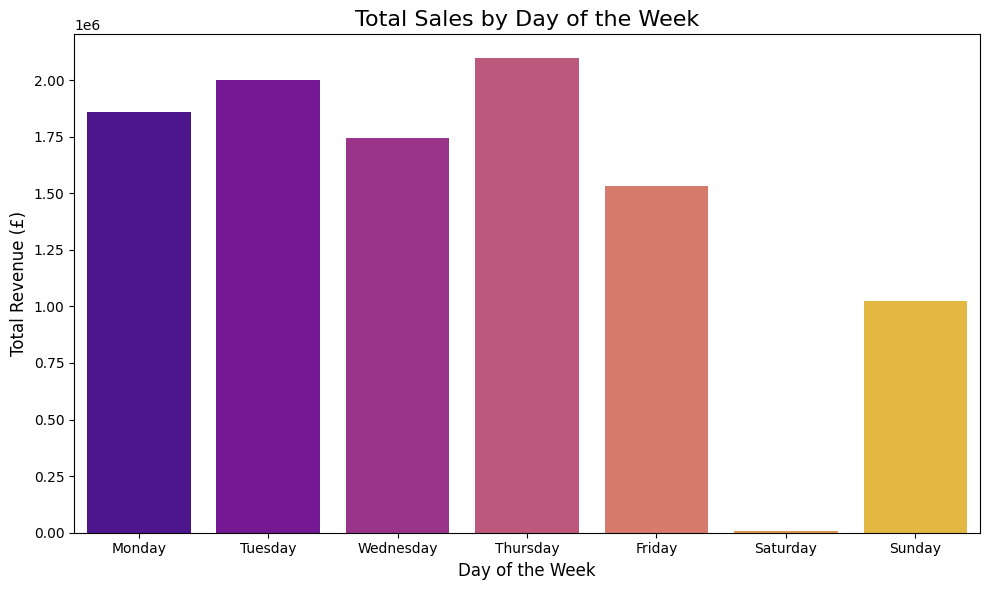

In [ ]:
plt.figure(figsize=(10, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = data.groupby('DayOfWeek')['Sales'].sum().reindex(day_order).reset_index()

sns.barplot(data=day_sales, x='DayOfWeek', y='Sales', palette='plasma')

plt.title('Total Sales by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.tight_layout()
plt.show()

## 5.2 - Orders per Hour

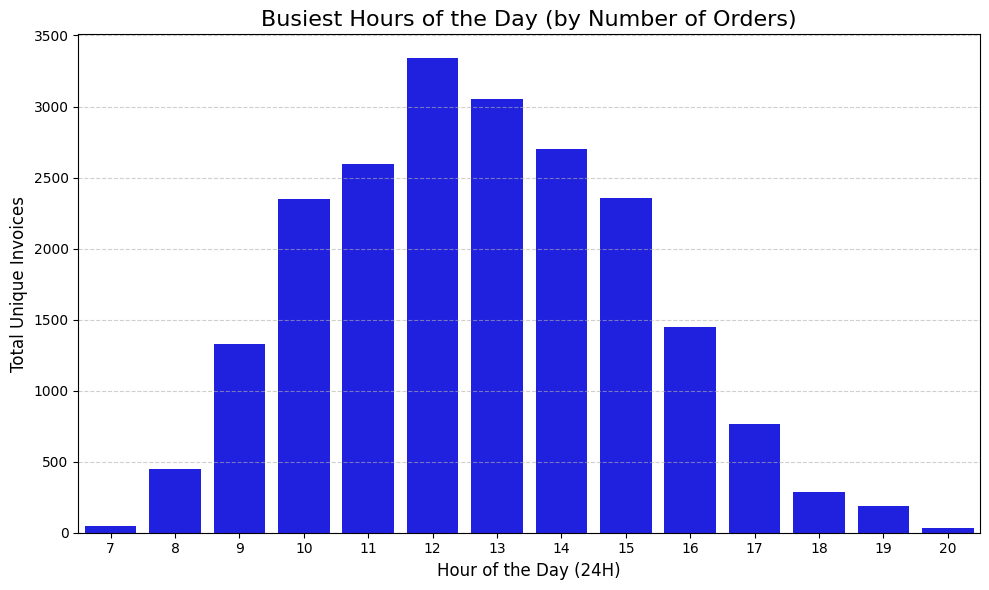

In [ ]:
plt.figure(figsize=(10, 6))

hourly_orders = data.groupby('Hour')['Invoice'].nunique().reset_index()

sns.barplot(data=hourly_orders, x='Hour', y='Invoice', color='blue')

plt.title('Busiest Hours of the Day (by Number of Orders)', fontsize=16)
plt.xlabel('Hour of the Day (24H)', fontsize=12)
plt.ylabel('Total Unique Invoices', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5.3 - Total sales

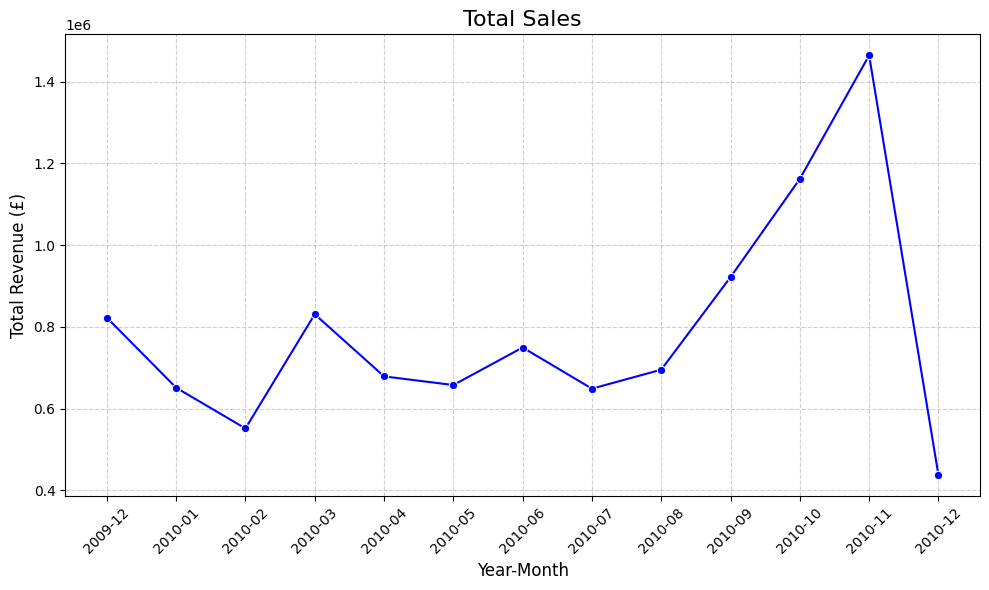

In [ ]:
plt.figure(figsize=(10, 6))

monthly_sales = data.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

monthly_sales['Period'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

sns.lineplot(data=monthly_sales, x='Period', y='Sales', marker='o', color='b')

plt.title('Total Sales', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5.4 - Revenue in each country

/tmp/ipykernel_21383/2008828915.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries_all, x='Sales', y='Country', palette='plasma', ax=axes[0])
/tmp/ipykernel_21383/2008828915.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries_intl, x='Sales', y='Country', palette='plasma', ax=axes[1])


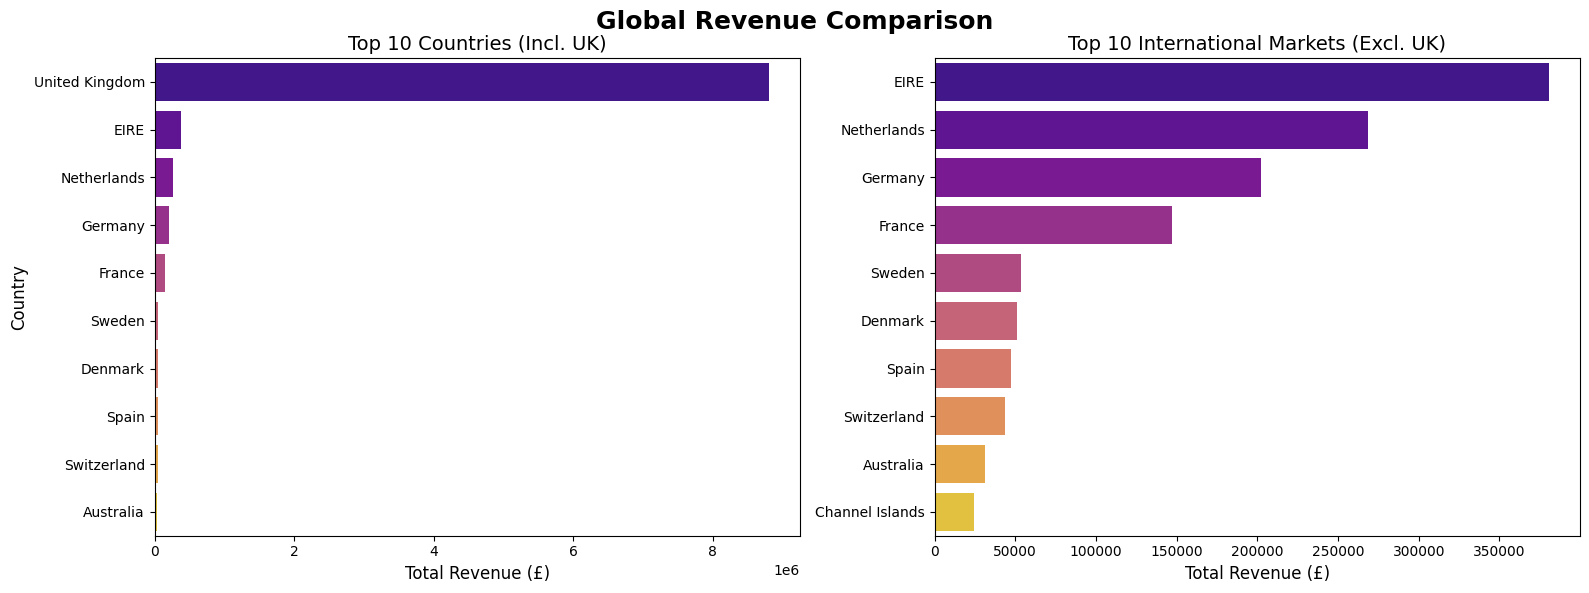

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


fig.suptitle('Global Revenue Comparison', fontsize=18, fontweight='bold')

# All Countries (Including UK)
top_countries_all = data.groupby('Country')['Sales'].sum().nlargest(10).reset_index()

sns.barplot(data=top_countries_all, x='Sales', y='Country', palette='plasma', ax=axes[0])

axes[0].set_title('Top 10 Countries (Incl. UK)', fontsize=14)
axes[0].set_xlabel('Total Revenue (£)', fontsize=12)
axes[0].set_ylabel('Country', fontsize=12)

# International Only (Excluding UK)
international_data = data[data['Country'] != 'United Kingdom']
top_countries_intl = international_data.groupby('Country')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(data=top_countries_intl, x='Sales', y='Country', palette='plasma', ax=axes[1])

axes[1].set_title('Top 10 International Markets (Excl. UK)', fontsize=14)
axes[1].set_xlabel('Total Revenue (£)', fontsize=12)
axes[1].set_ylabel('')


plt.tight_layout()

plt.subplots_adjust(top=0.90)

plt.show()

# Extracted Dataframe

In [ ]:
"""To download the data
data.to_csv('cleaned_online_retail.csv', index=False)

from google.colab import files
files.download('cleaned_online_retail.csv')"""

"To download the data\ndata.to_csv('cleaned_online_retail.csv', index=False)\n\nfrom google.colab import files\nfiles.download('cleaned_online_retail.csv')"